Loaded 135 true bids.

--- Simulating for V_guess=30 ---
Running 2 Monte Carlo simulations with 20000 rounds each...
Simulation 1/2
Simulation 2/2
Monte Carlo simulations completed.
Simulated bids generated in 3.82 seconds.


/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Co

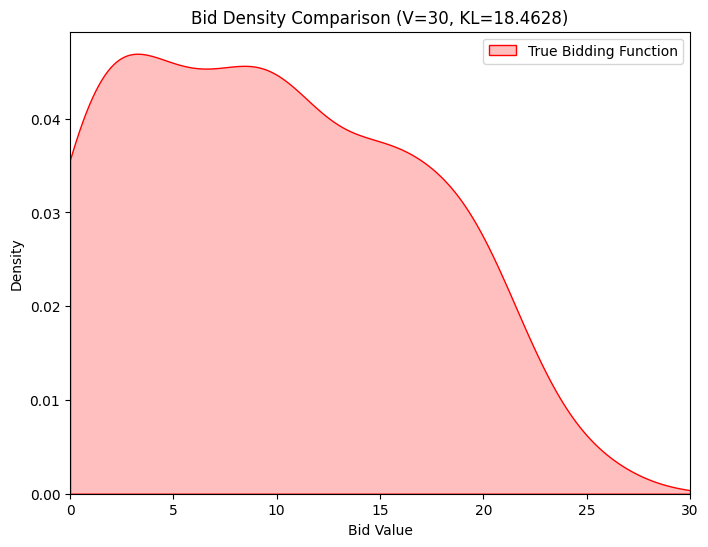

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
import time

# ===================== Section 1: Data Loading and Preparation =====================

def load_and_clean_data(filepath):
    data = pd.read_csv(filepath)
    filtered_data = data[(data['matched_info'] == 'yes') & 
                         (data[['bid_fp', 'bid_sp', 'bid_ap']] <= 30).all(axis=1)].copy()
    return filtered_data

def get_true_bids(filepath):
    data = load_and_clean_data(filepath)
    filtered_data = data[(data['bid_fp'] >= 0) & (data['bid_fp'] <= 30)].copy()
    true_bids = filtered_data['bid_fp'].values  # Extracting the true first-price bids
    print(f"Loaded {len(true_bids)} true bids.")
    return true_bids

# ===================== Section 2: Q-Learning Agents and Monte Carlo Simulation =====================

# Q-learning agent implementation
class QLearningAgent:
    def __init__(self, valuation_distribution=lambda: np.random.beta(2, 5), action_min=0, action_max=1, granularity=20, epsilon=0.1, alpha=0.1, gamma=0.95):
        self.valuation_distribution = valuation_distribution
        self.actions = np.linspace(action_min, action_max, granularity)  # Possible bids
        self.epsilon = epsilon  # Exploration rate
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.q_values = np.zeros((granularity, len(self.actions)))  # Q-table
        self.granularity = granularity
        self.current_state = 0

    def reset(self):
        self.current_state = 0

    def get_state(self, valuation):
        # Ensure the state index is within bounds [0, granularity-1]
        state_index = int(np.digitize(valuation, np.linspace(0, 1, self.granularity))) - 1
        return min(max(state_index, 0), self.granularity - 1)

    def choose_action(self):
        if np.random.rand() < self.epsilon:
            # Explore: Choose a random action
            return np.random.choice(self.actions)
        else:
            # Exploit: Choose the action with the highest Q-value
            return self.actions[np.argmax(self.q_values[self.current_state])]

    def update_q_values(self, reward, chosen_action):
        action_index = np.where(self.actions == chosen_action)[0][0]
        best_future_q = np.max(self.q_values[self.current_state])
        self.q_values[self.current_state, action_index] += self.alpha * (reward + self.gamma * best_future_q - self.q_values[self.current_state, action_index])

# Single Sided Auction Class with flexible reward function
class SingleSidedAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=1, payment_rule=None, a=1, b=0, c=0, d=0):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule
        self.a = a  # Constant term in the reward function
        self.b = b  # Coefficient for linear term in the reward function
        self.c = c  # Coefficient for quadratic term in the reward function
        self.d = d  # Coefficient for cubic term in the reward function

    def run_auction(self):
        valuations = [agent.valuation_distribution() for agent in self.agents]
        for i, agent in enumerate(self.agents):
            agent.current_state = agent.get_state(valuations[i])  # Set agent's current state

        bids = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]
        winner_index, payment = self.payment_rule(bids)
        
        # Provide feedback (reward) to agents based on the new reward function
        for idx, agent in enumerate(self.agents):
            if idx == winner_index:
                payoff = valuations[idx] - payment
                reward = self.a + self.b * payoff + self.c * (payoff ** 2) + self.d * (payoff ** 3)
            else:
                reward = 0
            agent.update_q_values(reward, bids[idx])

        return {"winner": winner_index, "payment": payment, "bids": bids}

# First price auction rule
def first_price_rule(bids):
    highest_bid = np.max(bids)
    potential_winners = np.where(bids == highest_bid)[0]
    winner = np.random.choice(potential_winners) if len(potential_winners) > 1 else potential_winners[0]
    payment = bids[winner]
    return winner, payment

# Monte Carlo simulation for Q-learning
def run_monte_carlo_simulation(agents, auction, num_simulations=30, num_rounds=10000):
    print(f"Running {num_simulations} Monte Carlo simulations with {num_rounds} rounds each...")
    simulated_bids = []
    for sim in range(num_simulations):
        print(f"Simulation {sim+1}/{num_simulations}")
        for round_num in range(num_rounds):
            auction.run_auction()  # Agents learn over multiple rounds
        simulation_round = []
        for agent_idx, agent in enumerate(agents):
            # After learning, store the final bidding strategy
            simulation_round.append(np.mean(agent.q_values, axis=1))  # Averaged learned bidding strategy
        simulated_bids.append(simulation_round)
    print("Monte Carlo simulations completed.")
    return simulated_bids

# ===================== Section 3: Valuation Guessing and Beta Distribution =====================

# Beta distribution for valuations with guessed parameters alpha, beta, and maximum valuation V
def beta_valuation(alpha, beta, max_valuation):
    return np.random.beta(alpha, beta) * max_valuation

# Function to simulate bids using the median bidding function
def simulate_bids_with_median_bidding(v_guess, agents, auction, num_simulations=10, num_rounds=20000):
    start_time = time.time()
    all_bids_for_valuations = run_monte_carlo_simulation(agents, auction, num_simulations=num_simulations, num_rounds=num_rounds)
    
    # Flatten the bids data for each agent across simulations and compute the median bidding function
    flattened_bids = np.array(all_bids_for_valuations).reshape(num_simulations, -1)
    
    # Compute the median bidding function across all simulations
    median_bidding_function = np.median(flattened_bids, axis=0)
    
    # Use this median bidding function with valuation range [0, V] to generate simulated bids
    valuations = np.linspace(0, v_guess, len(median_bidding_function))
    simulated_bids = np.interp(valuations, np.linspace(0, v_guess, len(median_bidding_function)), median_bidding_function)
    
    print(f"Simulated bids generated in {time.time() - start_time:.2f} seconds.")
    return simulated_bids

# Function to compute KL divergence between two bid distributions
def calculate_kl_divergence(true_bids, simulated_bids, num_bins=50):
    # Estimate densities using histograms
    true_hist, bin_edges = np.histogram(true_bids, bins=num_bins, density=True, range=(0, 30))
    sim_hist, _ = np.histogram(simulated_bids, bins=bin_edges, density=True, range=(0, 30))
    
    # Compute KL divergence (add small value to avoid division by zero)
    return entropy(true_hist + 1e-10, sim_hist + 1e-10)

# Simulated comparison for multiple values of V
def compare_simulation_to_true_bids_density(v_values, filepath, agents, auction, num_simulations=10, num_rounds=20000):
    # Get true bids from the dataset
    true_bids = get_true_bids(filepath)
    
    for v_guess in v_values:
        print(f"\n--- Simulating for V_guess={v_guess} ---")
        # Simulate the bids using the median bidding function for the guessed V
        simulated_bids = simulate_bids_with_median_bidding(v_guess, agents, auction, num_simulations=num_simulations, num_rounds=num_rounds)
        
        # Compute KL divergence between bid distributions
        kl_divergence = calculate_kl_divergence(true_bids, simulated_bids)
        
        # Plot the true and simulated bidding densities with bounds [0, 30]
        plt.figure(figsize=(8, 6))
        sns.kdeplot(true_bids, label='True Bidding Function', color='red', fill=True, clip=(0, 30))
        sns.kdeplot(simulated_bids, label=f'Simulated Bids (V={v_guess}, KL={kl_divergence:.4f})', linestyle='--', fill=True, clip=(0, 30))
        
        plt.xlabel('Bid Value')
        plt.ylabel('Density')
        plt.title(f'Bid Density Comparison (V={v_guess}, KL={kl_divergence:.4f})')
        plt.legend()
        plt.xlim(0, 30)  # Ensure the x-axis reflects the range [0, 30]
        plt.show()


# ===================== Example Usage =====================
# Example Usage
v_values = [30]  # Guessed valuation ranges
filepath = '/home/pp712/double-auctions/code/14_simple/clean_kaplan_data.csv'

# Set up Q-learning agents with a guessed uniform distribution
num_agents = 2
max_valuation_guess = 30

# Example 1: Truncated Normal Distribution for Valuations
from scipy.stats import truncnorm

def truncated_normal_valuation(mean=15, std=5, lower=0, upper=30):
    a, b = (lower - mean) / std, (upper - mean) / std
    return truncnorm.rvs(a, b, loc=mean, scale=std)

# Example 2: Shifted Beta Distribution for Valuations
def shifted_beta_valuation(alpha=2, beta=1, max_val=30):
    return np.random.beta(alpha, beta) * max_val

# Create agents with uniformly distributed valuations
agents_uniform = [
    QLearningAgent(valuation_distribution=lambda: np.random.uniform(0, max_valuation_guess)) 
    for _ in range(num_agents)
]

agents_beta= [
    QLearningAgent(valuation_distribution=lambda: np.random.beta(2, 3) * 30) 
    for _ in range(num_agents)
]

upper = 30
lower = 0
mean = 12
std = 16

a = (lower - mean) / std
b = (upper - mean) / std

agents_norm= [
    QLearningAgent(valuation_distribution=lambda: truncnorm.rvs(a,b, loc=mean, scale=std))
    for _ in range(num_agents)
]

# Set reward function parameters for the new reward formula, including a cubic term
a = 0  # Constant term
b = 1.0  # Linear term
c = 0.00 # Quadratic term
d = 0.00 # Cubic term

# Set up the auction and run simulations with the specified reward function
auction = SingleSidedAuction(agents_beta, payment_rule=first_price_rule, a=a, b=b, c=c, d=d)
compare_simulation_to_true_bids_density(v_values, filepath, agents_uniform, auction, num_simulations=2, num_rounds=20000)

Loaded 135 true bids.

--- Simulating for V_guess=30 ---
Running 2 Monte Carlo simulations with 20000 rounds each...
Simulation 1/2
Simulation 2/2
Monte Carlo simulations completed.
Simulated bids generated in 3.75 seconds.


/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Co

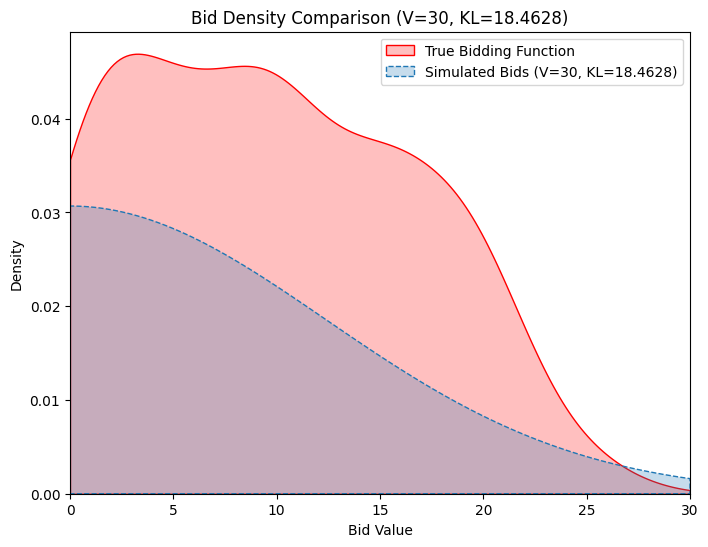

In [100]:
from scipy.stats import truncnorm

# Truncated normal distribution function
def truncated_normal_valuation(mean, std, lower_bound, upper_bound):
    a, b = (lower_bound - mean) / std, (upper_bound - mean) / std
    return truncnorm.rvs(a, b, loc=mean, scale=std)

# ===================== Example Usage =====================

# Example Usage
v_values = [30]  # Guessed valuation ranges
filepath = '/home/pp712/double-auctions/code/14_simple/clean_kaplan_data.csv'

# Set up Q-learning agents with a guessed Beta distribution
num_agents = 2
alpha_guess = 2
beta_guess = 3
max_valuation_guess = 30

# Create agents with Beta-distributed valuations
agents_beta = [
    QLearningAgent(valuation_distribution=lambda: beta_valuation(alpha_guess, beta_guess, max_valuation_guess)) 
    for _ in range(num_agents)
]

# Set reward function parameters for the new reward formula
a = 0.1  # Constant term
b = 1  # Linear term
c = -0.01  # Quadratic term

# Set up the auction and run simulations with the specified reward function
auction = SingleSidedAuction(agents_beta, payment_rule=first_price_rule, a=a, b=b, c=c)
compare_simulation_to_true_bids_density(v_values, filepath, agents_beta, auction, num_simulations=2, num_rounds=20000)

/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


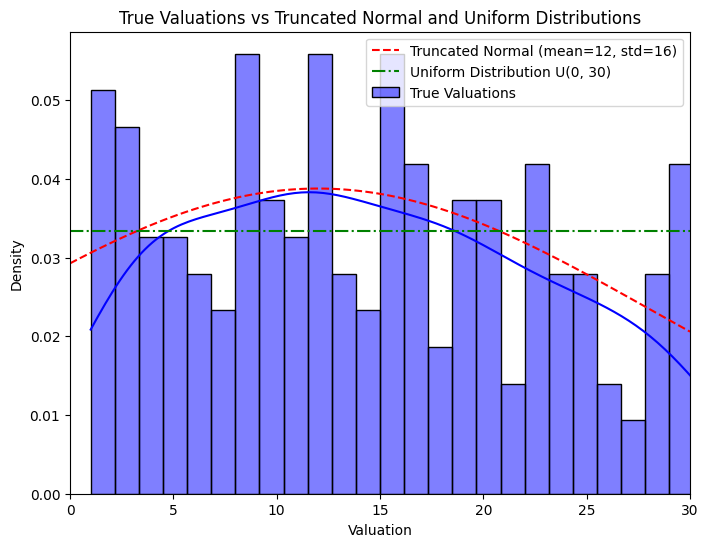

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import truncnorm, uniform

# Function to create a truncated normal distribution
def truncated_normal_pdf(x, mean, std, lower_bound, upper_bound):
    a, b = (lower_bound - mean) / std, (upper_bound - mean) / std
    return truncnorm.pdf(x, a, b, loc=mean, scale=std)

# Load data and extract the true valuations
def plot_true_valuations_with_truncated_normal_and_uniform(filepath, mean=15, std=5, lower_bound=0, upper_bound=30):
    data = pd.read_csv(filepath)
    true_valuations = data['value_fp'].values  # Assuming 'value_fp' contains true valuations
    
    # Generate Truncated Normal distribution PDF
    x = np.linspace(lower_bound, upper_bound, 100)
    truncated_normal_pdf_values = truncated_normal_pdf(x, mean, std, lower_bound, upper_bound)
    
    # Generate Uniform distribution PDF
    uniform_pdf = uniform.pdf(x, loc=lower_bound, scale=upper_bound - lower_bound)  # PDF for U(0, upper_bound)

    # Plot true valuation distribution
    plt.figure(figsize=(8, 6))
    sns.histplot(true_valuations, bins=30, kde=True, color='blue', stat= 'density', label='True Valuations')
    
    # Plot Truncated Normal PDF
    plt.plot(x, truncated_normal_pdf_values, label=f'Truncated Normal (mean={mean}, std={std})', color='red', linestyle='--')

    # Plot Uniform PDF
    plt.plot(x, uniform_pdf, label=f'Uniform Distribution U({lower_bound}, {upper_bound})', color='green', linestyle='-.')

    # Labels and title
    plt.xlabel('Valuation')
    plt.ylabel('Density')
    plt.title('True Valuations vs Truncated Normal and Uniform Distributions')
    plt.legend()
    plt.xlim(lower_bound, upper_bound)
    plt.show()

# Example usage
filepath = '/home/pp712/double-auctions/code/14_simple/clean_kaplan_data.csv'
plot_true_valuations_with_truncated_normal_and_uniform(filepath, mean=12, std=16, lower_bound=0, upper_bound=30)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
from scipy.stats import truncnorm
import statsmodels.api as sm

# ===================== Section 1: Data Loading and Preparation =====================

def load_and_clean_data(filepath):
    data = pd.read_csv(filepath)
    # Clean the data: remove bids > valuation and bids < 0
    cleaned_data = data[(data['matched_info'] == 'yes') & 
                        (data['bid_fp'] <= data['value_fp']) & 
                        (data['bid_fp'] >= 0) &
                        (data['value_fp'] <= 30) &
                        (data['value_fp'] >= 0)]
    return cleaned_data

def get_true_bids(filepath):
    data = load_and_clean_data(filepath)
    true_valuations = data['value_fp'].values  # Extracting valuations
    true_bids = data['bid_fp'].values  # Extracting first-price auction bids
    print(f"Loaded {len(true_bids)} true bids.")
    return true_valuations, true_bids

def observed_bidding_function(filepath):
    data = load_and_clean_data(filepath)
    
    # Regression: bid on valuation and valuation^2 without a constant
    data['valuation_squared'] = data['value_fp'] ** 2
    X = data[['value_fp', 'valuation_squared']]  # Independent variables
    y = data['bid_fp']  # Dependent variable (bids)
    
    model = sm.OLS(y, X).fit()  # Regression without a constant
    print(model.summary())
    
    return model

# ===================== Section 2: Q-Learning Agents and Monte Carlo Simulation =====================

# Q-learning agent implementation
class QLearningAgent:
    def __init__(self, valuation_distribution=lambda: np.random.uniform(0, 30), action_min=0, action_max=1, granularity=20, epsilon=0.1, alpha=0.1, gamma=0.95):
        self.valuation_distribution = valuation_distribution
        self.actions = np.linspace(action_min, action_max, granularity)  # Possible bids
        self.epsilon = epsilon  # Exploration rate
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.q_values = np.zeros((granularity, len(self.actions)))  # Q-table
        self.granularity = granularity
        self.current_state = 0

    def reset(self):
        self.current_state = 0

    def get_state(self, valuation):
        # Ensure the state index is within bounds [0, granularity-1]
        state_index = int(np.digitize(valuation, np.linspace(0, 30, self.granularity))) - 1
        return min(max(state_index, 0), self.granularity - 1)

    def choose_action(self):
        if np.random.rand() < self.epsilon:
            # Explore: Choose a random action
            return np.random.choice(self.actions)
        else:
            # Exploit: Choose the action with the highest Q-value
            return self.actions[np.argmax(self.q_values[self.current_state])]

    def update_q_values(self, reward, chosen_action):
        action_index = np.where(self.actions == chosen_action)[0][0]
        best_future_q = np.max(self.q_values[self.current_state])
        self.q_values[self.current_state, action_index] += self.alpha * (reward + self.gamma * best_future_q - self.q_values[self.current_state, action_index])

# ===================== Section 3: Auction Setup and Simulation =====================

# Single Sided Auction Class with flexible reward function
class SingleSidedAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=30, payment_rule=None, a=1, b=0, c=0, d=0):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule
        self.a = a  # Constant term in the reward function
        self.b = b  # Coefficient for linear term in the reward function
        self.c = c  # Coefficient for quadratic term in the reward function
        self.d = d  # Coefficient for cubic term in the reward function

    def run_auction(self):
        valuations = [agent.valuation_distribution() for agent in self.agents]
        for i, agent in enumerate(self.agents):
            agent.current_state = agent.get_state(valuations[i])  # Set agent's current state

        bids = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]
        winner_index, payment = self.payment_rule(bids)
        
        # Provide feedback (reward) to agents based on the new reward function
        for idx, agent in enumerate(self.agents):
            if idx == winner_index:
                payoff = valuations[idx] - payment
                reward = self.a + self.b * payoff + self.c * (payoff ** 2) + self.d * (payoff ** 3)
            else:
                reward = 0
            agent.update_q_values(reward, bids[idx])

        return {"winner": winner_index, "payment": payment, "bids": bids}

# First price auction rule
def first_price_rule(bids):
    highest_bid = np.max(bids)
    potential_winners = np.where(bids == highest_bid)[0]
    winner = np.random.choice(potential_winners) if len(potential_winners) > 1 else potential_winners[0]
    payment = bids[winner]
    return winner, payment

# Monte Carlo simulation for Q-learning
def run_monte_carlo_simulation(agents, auction, num_simulations=30, num_rounds=10000):
    simulated_bids = []
    for sim in range(num_simulations):
        for round_num in range(num_rounds):
            auction.run_auction()  # Agents learn over multiple rounds
        simulation_round = []
        for agent_idx, agent in enumerate(agents):
            simulation_round.append(np.mean(agent.q_values, axis=1))  # Averaged learned bidding strategy
        simulated_bids.append(simulation_round)
    return simulated_bids

# ===================== Section 4: Simulation, Regression, and Plotting =====================

# Function to simulate bids using the median bidding function
def simulate_bids_with_median_bidding(v_guess, agents, auction, num_simulations=10, num_rounds=20000):
    all_bids_for_valuations = run_monte_carlo_simulation(agents, auction, num_simulations=num_simulations, num_rounds=num_rounds)
    
    # Flatten the bids data for each agent across simulations and compute the median bidding function
    flattened_bids = np.array(all_bids_for_valuations).reshape(num_simulations, -1)
    
    # Compute the median bidding function across all simulations
    median_bidding_function = np.median(flattened_bids, axis=0)
    
    return median_bidding_function

# ===================== Section 5: Plotting Bidding Functions =====================

def plot_bidding_functions(filepath, simulated_bidding_function, v_guess):
    # Get true bids and observed regression model
    true_valuations, true_bids = get_true_bids(filepath)
    observed_model = observed_bidding_function(filepath)

    # Create valuation grid for plotting
    valuation_grid = np.linspace(0, v_guess, 100)

    # Get predicted bids from the observed regression model
    observed_bids = observed_model.predict(np.column_stack((valuation_grid, valuation_grid ** 2)))

    # Plot observed vs simulated bidding functions
    plt.figure(figsize=(8, 6))
    plt.plot(valuation_grid, observed_bids, label='Observed Bidding Function', color='red')
    plt.plot(valuation_grid, simulated_bidding_function, label='Simulated Bidding Function', color='blue', linestyle='--')
    plt.xlabel('Valuation')
    plt.ylabel('Bid')
    plt.title('Observed vs Simulated Bidding Functions')
    plt.legend()
    plt.show()

# ===================== Example Usage =====================
v_values = [30]  # Guessed valuation ranges
filepath = '/home/pp712/double-auctions/code/14_simple/clean_kaplan_data.csv'

# Set up Q-learning agents with uniform distribution
num_agents = 2
agents_uniform = [
    QLearningAgent(valuation_distribution=lambda: np.random.uniform(0, 30)) 
    for


SyntaxError: incomplete input (1335153718.py, line 174)